## Análise de Risco de Crédito: Ingestão e Engenharia de Features

**Objetivo:** Consumir os dados originais do *German Credit Dataset* (UCI), realizar a análise exploratória inicial e aplicar o *One-Hot Encoding* nas variáveis categóricas preparando a base para modelagem.

Dados do site: https://archive.ics.uci.edu/dataset/144/statlog+german+credit+data 

In [24]:
from ucimlrepo import fetch_ucirepo
  
statlog_german_credit_data = fetch_ucirepo(id=144)
  
X = statlog_german_credit_data.data.features
y = statlog_german_credit_data.data.targets
  
print(statlog_german_credit_data.metadata)
  
print(statlog_german_credit_data.variables)

{'uci_id': 144, 'name': 'Statlog (German Credit Data)', 'repository_url': 'https://archive.ics.uci.edu/dataset/144/statlog+german+credit+data', 'data_url': 'https://archive.ics.uci.edu/static/public/144/data.csv', 'abstract': 'This dataset classifies people described by a set of attributes as good or bad credit risks. Comes in two formats (one all numeric). Also comes with a cost matrix', 'area': 'Social Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 1000, 'num_features': 20, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Other', 'Marital Status', 'Age', 'Occupation'], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1994, 'last_updated': 'Thu Aug 10 2023', 'dataset_doi': '10.24432/C5NC77', 'creators': ['Hans Hofmann'], 'intro_paper': None, 'additional_info': {'summary': 'Two datasets are provided.  the original dataset, in the form provided by

## Análise de Balanceamento e Outliers

Nesta etapa, entenderemos a distribuição individual dos dados.Primeiro, foi verificada a proporção da variável alvo para identificar se o dataset sofre de desbalanceamento severo (algo comum em cenários de fraude e crédito). Em seguida, utilizamos boxplots nas variáveis numéricas para mapear possíveis outliers que possam distorcer o aprendizado do algoritmo.

> **Nota sobre as variáveis categóricas:** Para as outras 13 variáveis qualitativas (como Histórico de Crédito ou Status da Conta), eventuais desbalanceamentos e "categorias raras" serão avaliados visualmente através da análise de frequência (gráficos de barras) na etapa bivariada.

> **Nota de Negócios:** Os *outliers* detectados nas variáveis contínuas (como altos valores de crédito, prazos longos ou idade avançada) representam perfis financeiros reais e não erros de sistema. Portanto, **eles não serão removidos da base**. Eliminar esses dados deixaria o modelo "cego" justamente para as operações mais sensíveis e de alto risco.

--- BALANCEAMENTO DA VARIÁVEL ALVO ---
             Quantidade  Percentual (%)
class_label                            
Bom (1)             700            70.0
Risco (2)           300            30.0


--- DETECÇÃO DE OUTLIERS (VARIÁVEIS NUMÉRICAS) ---


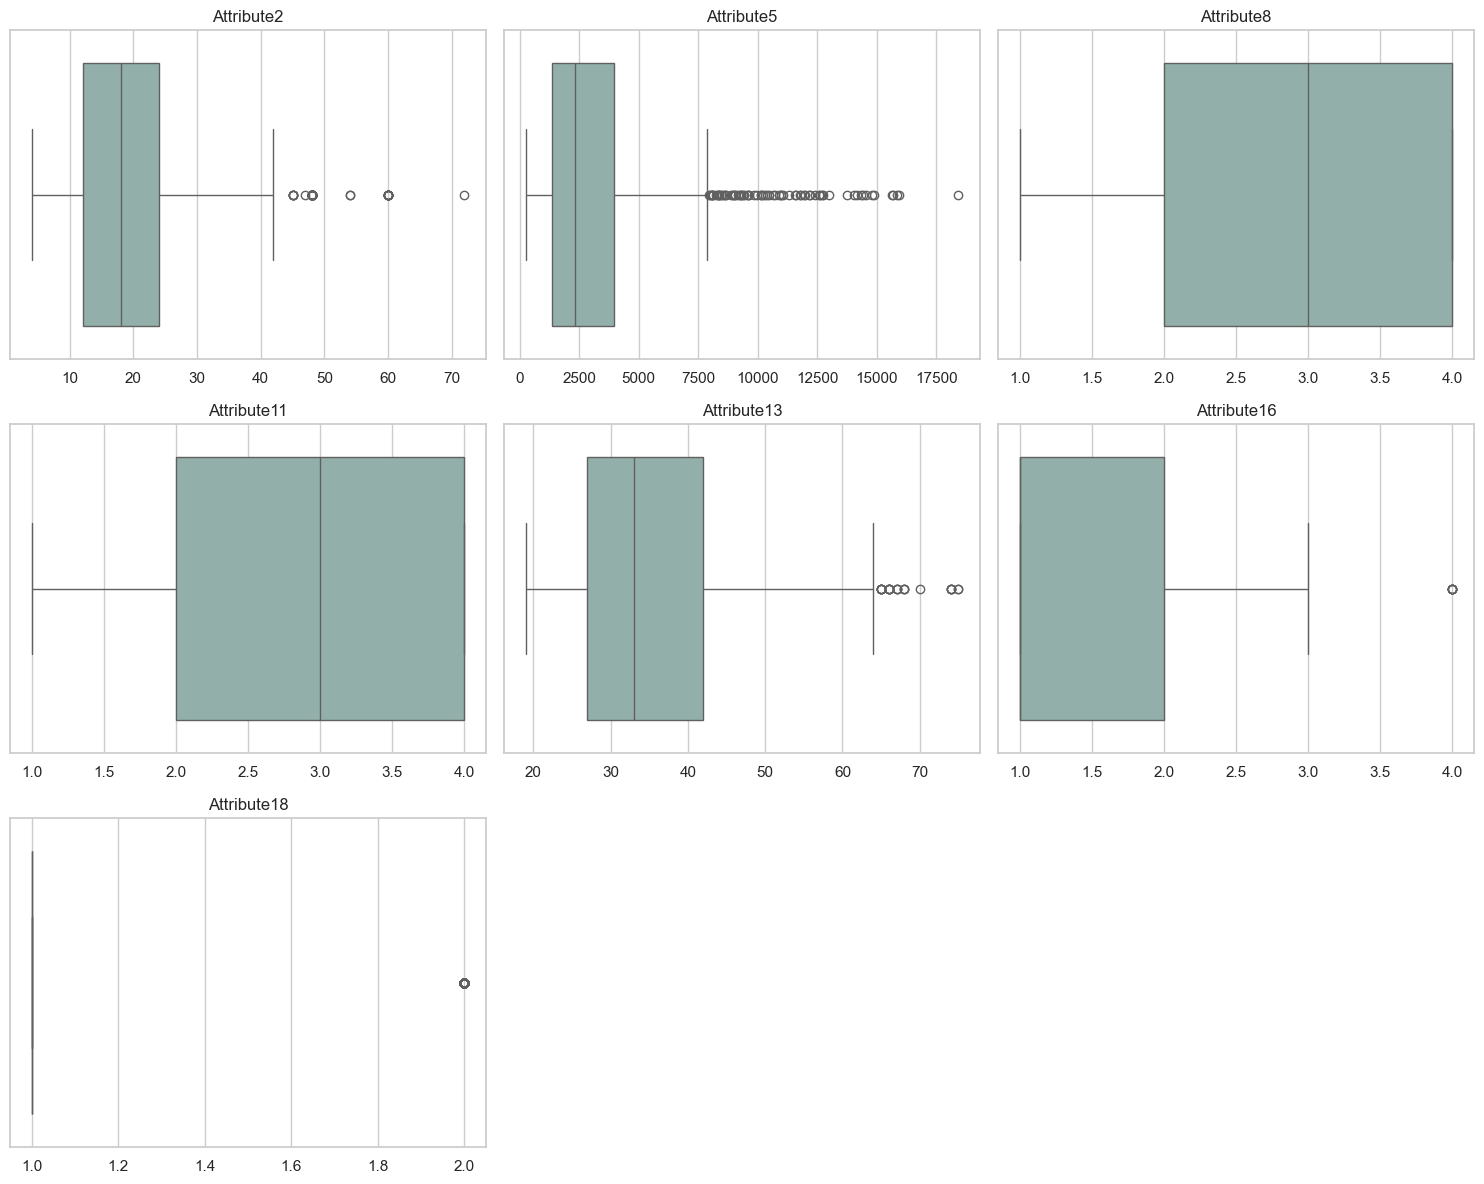

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

#Proporção da variável alvo
print("--- BALANCEAMENTO DA VARIÁVEL ALVO ---")
contagem = df_eda['class_label'].value_counts()
percentual = df_eda['class_label'].value_counts(normalize=True) * 100

resumo_alvo = pd.DataFrame({
    'Quantidade': contagem,
    'Percentual (%)': percentual.round(2)
})
print(resumo_alvo)
print("\n")

#Boxplots para detectar Outliers nas variáveis numéricas
print("--- DETECÇÃO DE OUTLIERS (VARIÁVEIS NUMÉRICAS) ---")

linhas_box = math.ceil(len(colunas_numericas) / 3)
plt.figure(figsize=(15, 4 * linhas_box))

for i, coluna in enumerate(colunas_numericas, 1):
    plt.subplot(linhas_box, 3, i)
    sns.boxplot(data=df_eda, x=coluna, color='#8DB4AD')
    plt.title(f'{coluna}', fontsize=12)
    plt.xlabel('')

plt.tight_layout()
plt.show()


## Análise Bivariada: O Perfil do Risco

Com a base validada e o desbalanceamento mapeado, o objetivo agora é cruzar as nossas 20 variáveis com a variável alvo. O intuito é responder à principal pergunta de negócios: **Quais características diferenciam um bom pagador de um cliente de alto risco?**

Os gráficos abaixo exploram essas relações para extrairmos os *insights* que guiarão o algoritmo preditivo.

In [ ]:
from sklearn.model_selection import train_test_split

print("--- DIVISÃO DA BASE DE DADOS (65% / 15% / 20%) ---")

X = df_eda.drop(['class', 'class_label'], axis=1, errors='ignore')
y = df_eda['class'] 

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, 
    test_size=0.35, 
    random_state=42, 
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, 
    test_size=(20/35), 
    random_state=42, 
    stratify=y_temp
)

resumo_split = pd.DataFrame({
    'Base': ['Treino', 'Validação', 'Teste'],
    'Linhas': [X_train.shape[0], X_val.shape[0], X_test.shape[0]],
    'Proporção (%)': [
        len(X_train)/len(X)*100, 
        len(X_val)/len(X)*100, 
        len(X_test)/len(X)*100
    ]
})

print(resumo_split.to_string(index=False))

--- DIVISÃO DA BASE DE DADOS (65% / 15% / 20%) ---
     Base  Linhas  Proporção (%)
   Treino     650           65.0
Validação     150           15.0
    Teste     200           20.0
